[Chapter 4](04_Stationarity.ipynb) defined stationarity and built a gallery of processes that satisfy it and processes that do not. 
That chapter left one question open: given a real series, and no knowledge of the process behind it, **how do you decide?** And once you have decided it is nonstationary, **what do you do about it?**

# Learning objectives

By the end of this lecture you should be able to:

1. Diagnose nonstationarity from a **run-sequence plot**, **chunk statistics** and **rolling statistics**, and say *which* stationarity condition each symptom violates.
2. Run and interpret the **Augmented Dickey-Fuller** test, including the effect of the `regression` argument, and explain why "failed to reject" is not the same as "nonstationary".
3. Run the **KPSS** test, whose null hypothesis is the opposite one, and combine the two verdicts.
4. State what these tests do **not** see -- changing variance, seasonality, structural breaks -- and why they lose power on short samples.
5. Apply and invert the four workhorse transformations: **detrending/deseasonalising**, **log/Box-Cox**,
   **differencing** and **seasonal differencing**, in the right order.
6. Recognise **over-differencing**, and choose $d$ and $D$ for a real seasonal series.


# Setup

Modules and functions used in this lecture.

| Module | Used for |
|---|---|
| `numpy` | `random.default_rng`, `cumsum`, `diff`, `log`, `array_split` |
| `pandas` | `read_csv`, `Series`, `asfreq`, `diff`, `rolling`, `DataFrame` |
| `matplotlib.pyplot` | `subplots`, `plot`, `bar` |
| `scipy.stats` | `boxcox` |
| `statsmodels.tsa.stattools` | **`adfuller`** (ADF test), **`kpss`** (KPSS test), `acf` |
| `statsmodels.tsa.seasonal` | `seasonal_decompose` |
| `statsmodels.graphics.tsaplots` | `plot_acf` |
| `statsmodels.tsa.arima_process` | `ArmaProcess` (to rebuild the Chapter 4 examples) |

The setup cell is the same one used in Chapter 4, so the two notebooks can be run in either order.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.integrate import quad
from scipy.stats import pearsonr, boxcox

import statsmodels.api as sm
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf

# Two kinds of expected noise we do not want in the output:
#  - KPSS warns whenever its p-value falls outside the lookup table (that IS the answer, not an error);
#  - statsmodels 0.15 announces a future change to the return type of adfuller/kpss.
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", InterpolationWarning)
warnings.simplefilter("ignore", FutureWarning)

# Reproducibility: one generator, seeded once.
rng = np.random.default_rng(8990)

print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")
print(f"matplotlib  {mpl.__version__}")
print(f"seaborn     {sns.__version__}")
print(f"statsmodels {sm.__version__}")

pandas      2.3.3
numpy       2.3.2
matplotlib  3.10.6
seaborn     0.13.2
statsmodels 0.15.0


One helper we will reuse throughout: a **run-sequence plot** is simply the value plotted against time.
It is the first diagnostic for stationarity and we will draw dozens of them.

In [2]:
def run_sequence_plot(y, x=None, title="", xlabel="time", ylabel="value",
                      ax=None, figsize=(9, 3), color="blue", **kwargs):
    "Plot a series against time and return the axes."
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    if x is None:
        x = getattr(y, "index", np.arange(len(y)))
    ax.plot(x, y, color=color, lw=1, **kwargs)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.grid(alpha=0.3)
    return ax

Finally, the example series from Chapter 4. They are **regenerated here** from the same recipes so that this
notebook runs on its own; the draws are new, so the plots look the same but the individual numbers differ
from Chapter 4.

Keep in mind throughout this chapter that each of these is **one realization**. A random walk of 300 steps
that happens to wander back to where it started will test as stationary, and a short stationary series can
easily test as nonstationary -- see Section 5.5 and Exercise 4.

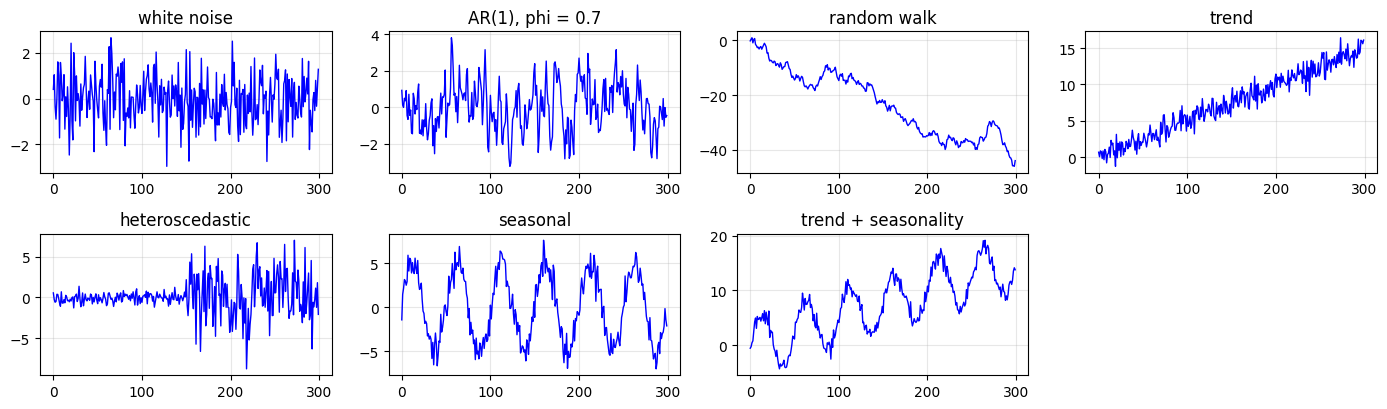

In [3]:
rng = np.random.default_rng(8999)          # reset, so this notebook is reproducible on its own

n = 300
t = np.arange(n)

white_noise   = rng.normal(0.0, 1.0, n)                                   # stationary reference
ar1           = ArmaProcess(ar=np.r_[1, -0.7], ma=np.r_[1]).generate_sample(n, distrvs=rng.standard_normal)
random_walk   = np.cumsum(rng.normal(size=n))                             # unit root
trend_series  = 0.05 * t + rng.normal(0, 1, n)                            # mean not constant
hetero_series = np.r_[rng.normal(0, 0.5, n // 2), rng.normal(0, 3.0, n - n // 2)]   # variance not constant
season_series = 5 * np.sin(2 * np.pi * t / 50) + rng.normal(0, 1, n)      # fixed-period seasonality
trend_season  = 0.05 * t + 5 * np.sin(2 * np.pi * t / 50) + rng.normal(0, 1, n)

chapter4 = {
    "white noise":         white_noise,
    "AR(1), phi = 0.7":    ar1,
    "random walk":         random_walk,
    "trend":               trend_series,
    "heteroscedastic":     hetero_series,
    "seasonal":            season_series,
    "trend + seasonality": trend_season,
}

fig, axes = plt.subplots(2, 4, figsize=(14, 4.2))
for ax, (name, s) in zip(axes.ravel(), chapter4.items()):
    run_sequence_plot(s, title=name, ax=ax, xlabel="", ylabel="")
axes.ravel()[-1].axis("off")
plt.tight_layout(); plt.show()

# Detecting stationarity

Four tools, used in this order: **look at it**, **split it and compare**, **roll a window through it**, **test it**. 
The tests come last because they answer a narrow question and are easy to misread.

Specifically, we will cover:
1. Run-sequence plots
2. Summary statistics
3. Augmented Dickey-Fuller test

## Run-sequence plots

Plot the series against time:

* a **trend** (level drifting up or down);
* a **funnel** or changing amplitude (heteroscedasticity);
* a **repeating pattern** locked to the calendar (seasonality);
* **long excursions** away from the mean that never return quickly (unit-root behaviour);
* **level shifts** or **variance breaks** (structural change -- which the tests below handle badly).

This step is not optional. Every plot in the Chapter 4 gallery was diagnosed correctly by eye.

## Chunk statistics

A stationary series must look the same in every window. 
So split the record into $m$ contiguous chunks and compare their means and variances. 
This is a heuristic -- there is no p-value -- but it makes the failure mode visible: is the *level* moving, the *spread*, or both?

In [31]:
# split data into 10 chunks
chunks = np.split(white_noise, indices_or_sections=10)

In [32]:
print("{}\t | {}\t\t | {}".format("Chunk", "Mean", "Variance"))
print("-" * 35)
for i, chunk in enumerate(chunks, 1):
    print("{:2}\t | {:.5}\t | {:.5}".format(i, np.mean(chunk), np.var(chunk)))

Chunk	 | Mean		 | Variance
-----------------------------------
 1	 | 0.081054	 | 1.3271
 2	 | 0.048793	 | 0.8482
 3	 | 0.19899	 | 1.5539
 4	 | 0.18174	 | 0.73471
 5	 | -0.13484	 | 0.84222
 6	 | -0.16264	 | 1.1773
 7	 | -0.2479	 | 0.9683
 8	 | -0.12375	 | 0.86221
 9	 | -0.08519	 | 1.2701
10	 | -0.076626	 | 0.85837


The pattern is diagnostic: the **trend** moves the chunk *means*, the **heteroscedastic** series moves the
chunk *variances*, the **random walk** moves both in an erratic way, and white noise moves neither beyond
sampling noise.

## Augmented Dickey-Fuller (ADF) test

The ADF test is a statistical procedure to determine whether a time series is stationary or not. 
The ADF test asks a specific question: **does the series contain a unit root?** It fits

$$
\Delta x_t \;=\; \alpha \;+\; \beta t \;+\; \gamma\, x_{t-1} \;+\; \sum_{i=1}^{p}\delta_i \Delta x_{t-i} \;+\; \varepsilon_t
$$

and tests have **two hypotheses**:

* **Null hypothesis:** $H_0:\ \gamma = 0$ -- There **is** a unit root, the series is **nonstationary**;
* **Alternative hypothesis:** $H_1:\ \gamma < 0$ -- No unit root, the series is stationary.

Reading the output:

* the **test statistic** is negative; the **more negative**, the stronger the evidence against $H_0$;
* reject $H_0$ when the statistic is below the critical value, or equivalently when
  **p-value $< \alpha$** (we use $\alpha = 0.05$);
* The values $\alpha=0.05$ or $\alpha=0.01$, which yield a confidence of $95\%$ and $99\%$, respectively, are common choices;
* $p < 0.05 \Rightarrow$ **stationary**; $p \geq 0.05 \Rightarrow$ *failed to reject* nonstationarity, which is not the same as proving nonstationarity.

### Stationary Data & ADF

Let's see how to run the ADF test using `adfuller(time_eries, regression)` in Python.
The `regression` argument sets the deterministic terms included, and it changes the answer:

| `regression` | Model includes | Use when |
|---|---|---|
| `'n'` | nothing | series already centred at 0 |
| `'c'` (default) | constant | series fluctuates around a nonzero level |
| `'ct'` | constant + linear trend | testing for stationarity **around a trend** |
| `'ctt'` | constant + linear + quadratic trend | rarely |



Let's see and comment the main outputs from the ADF test.

In [7]:
T = 200
time = np.arange(T)
stationary = np.random.normal(loc=0, scale=1.0, size=(T))

adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(stationary)

In [8]:
print(f"ADF: {adf:.2f}")

ADF: -11.37


- `adf` is the value of the test statistic.
- The more negative the value, the more confident we can be that the series is stationary.
- That may not mean anything to you just yet but `pvalue` should.

In [9]:
print(f"p-value: {pvalue}")

p-value: 8.975134909583032e-21


- The `pvalue` should be compared with the confidence levels (e.g., $\alpha=0.05$ or $\alpha=0.01$).
- Based on the comparison, we reject or fail to reject $H_0$. 
- Here ``pvalue`` is very close to zero so we **reject** the $H_0$ in favor of $H_A$ and conclude that the time series is stationary.

In [10]:
print(f"nobs: {nobs}")

nobs: 198


- The variable `nobs` is simply the number of observations in the time series.

In [11]:
print(f"critical values: {critical_values}")

critical values: {'1%': np.float64(-3.4638151713286316), '5%': np.float64(-2.876250632135043), '10%': np.float64(-2.574611347821651)}


- Finally, ``critical_values`` are the test statistic thresholds for common significant levels. 
- Here, we see a test statistic lower than -2.87 is sufficient to reject $H_0$ at a significance level of 5%.

- You may have noticed two outputs we didn't discuss. 
- See [statsmodels docs](http://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html) for a description of ``usedlag`` and ``icbest``.

**Example:** ADF on time series with trend

In [12]:
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(trend_series, regression='c')
print(f"ADF: {adf:.2f}")
print(f"p-value: {pvalue:.3f}")

ADF: 0.14
p-value: 0.968


As expected, we fail to reject $H_0$ that the `trend` time series is nonstationary.

**Example:** ADF on random walk

In [13]:
adf, pvalue, usedlag, nobs, critical_values, icbest = adfuller(random_walk, regression='c')
print(f"ADF: {adf:.2f}")
print(f"p-value: {pvalue:.3f}")

ADF: -0.90
p-value: 0.787


- As we discussed before, the random walk is nonstationary because its variance $\sigma^2t$ is not constant over time.
- In the next section, we'll learn how to make this time series stationary.

# Common transformations

If the series is not stationary, transform it. Four workhorses, and the condition each one repairs:

| Transformation | Repairs | Typical use |
|---|---|---|
| Subtract trend and/or seasonal component | condition 1 (mean) | after `seasonal_decompose`, model the residual |
| **Log** or **Box-Cox** | condition 2 (variance) | amplitude grows with the level (multiplicative behaviour) |
| **Differencing** $\Delta x_t = x_t - x_{t-1}$ | conditions 1 & 3 | trend / unit root |
| **Seasonal differencing** $\Delta_L x_t = x_t - x_{t-L}$ | condition 1 (seasonal mean) | fixed-period seasonality |

**Order matters**: stabilise the variance *first* (log), then remove seasonality, then remove the trend.
Sometimes you'll have to do multiple transformations on the same dataset.

## Subtract trend and seasonality

Time series decomposition gives $x_t = T_t + S_t + R_t$; the residual $R_t$ is what remains after both offending components are removed, and it is the piece we test.

Let's run the ADF test for `trend + seasonality` before transforming.

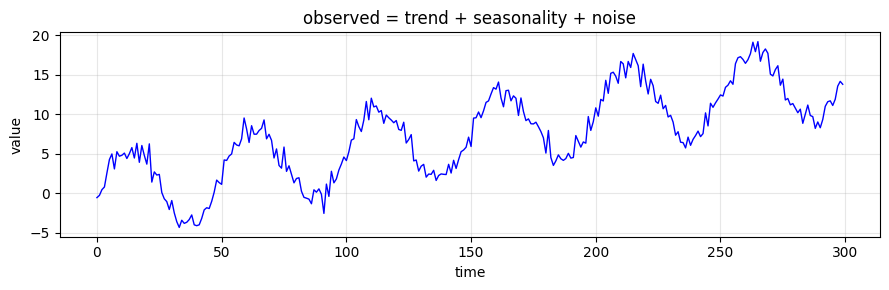

ADF: -1.84
p-value: 0.360


In [14]:
run_sequence_plot(trend_season, title="observed = trend + seasonality + noise")
plt.tight_layout(); plt.show()

adf_ts, pvalue_ts, _, _, _, _ = adfuller(trend_season)
print(f"ADF: {adf_ts:.2f}")
print(f"p-value: {pvalue_ts:.3f}")

- Nonstationary as expected. 
- Next, we apply the decomposition.

In [15]:
ss_decomposition = seasonal_decompose(x=trend_season, model='additive', period=50)
est_trend = ss_decomposition.trend
est_seasonal = ss_decomposition.seasonal
est_residual = ss_decomposition.resid

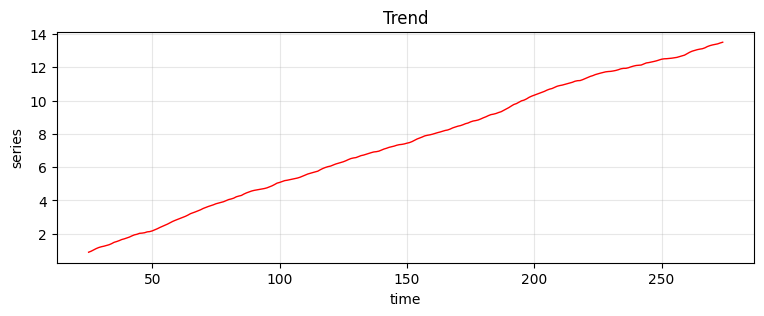

In [16]:
run_sequence_plot(est_trend, title="Trend", ylabel="series", color="red");

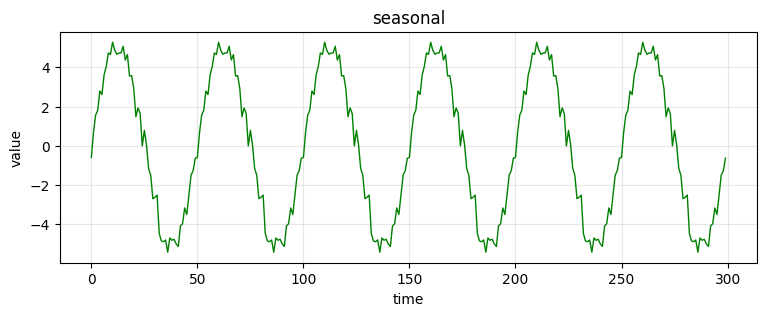

In [17]:
run_sequence_plot(est_seasonal, title="seasonal", color="green");

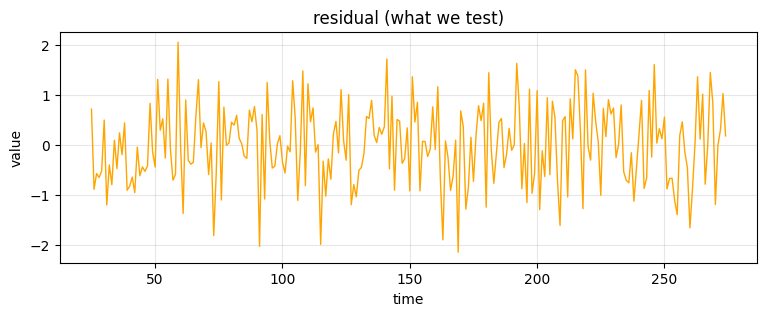

In [18]:
run_sequence_plot(est_residual, title="residual (what we test)", color="orange");

In [19]:
print(est_residual[:30])
print('...')
print(est_residual[-30:])

adf_after, pvalue_after, _, _, _, _ = adfuller(est_residual[25:-25])
print(f"ADF: {adf_after:.2f}")
print(f"p-value: {pvalue_after:.3f}")

[        nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan  0.71458032 -0.88825999 -0.57396429 -0.65243023 -0.51675134]
...
[-1.1918178  -0.00745858  0.30579933  1.02633147  0.17962334         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan]
ADF: -16.55
p-value: 0.000


- Now the time series is stationary!

## Log and Box-Cox -- stabilizing the variance

When the fluctuations grow with the level, the series is behaving *multiplicatively*:
$x_t = T_t \cdot S_t \cdot R_t$. Taking logs turns that product into a sum, and the seasonal swings become
constant in width:

$$\log x_t = \log T_t + \log S_t + \log R_t .$$

Two practical points:

- This trick is useful when dealing with heteroskedastic data. 
- The `log(time_series)` squashes the parts of the time series where the variance is higher.
- **Box-Cox** generalizes it, $x^{(\lambda)} = (x^{\lambda}-1)/\lambda$ for $\lambda \neq 0$ and $\log x$ for $\lambda = 0$; `scipy.stats.boxcox` picks $\lambda$ by maximum likelihood.

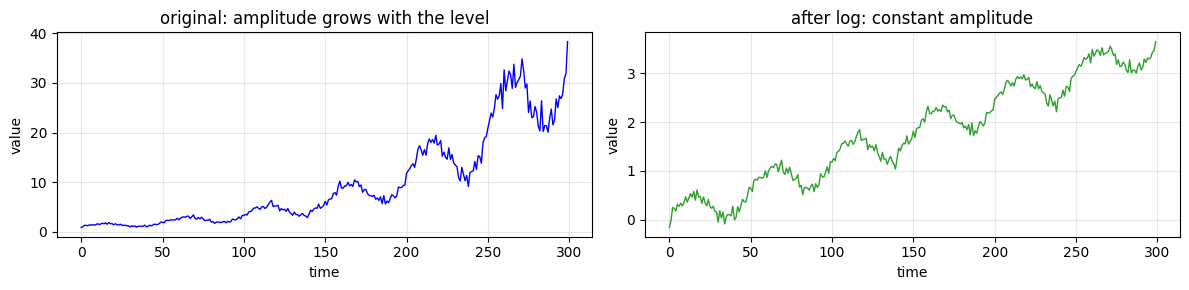

chunk variances, original : [ 0.18  1.44  5.57 17.64 35.47]
chunk variances, log      : [0.0707 0.1255 0.1531 0.1419 0.0714]

Box-Cox lambda = -0.0061


In [20]:
n = 300
t = np.arange(n)
multiplicative = np.exp(0.012 * t) * (1 + 0.35 * np.sin(2 * np.pi * t / 50)) * np.exp(rng.normal(0, .08, n))

log_series = np.log(multiplicative)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
run_sequence_plot(multiplicative, title="original: amplitude grows with the level", ax=axes[0])
run_sequence_plot(log_series,     title="after log: constant amplitude", ax=axes[1], color="tab:green")
plt.tight_layout(); plt.show()

print("chunk variances, original :", np.round(chunk_stats(multiplicative, 5)["var"].values, 2))
print("chunk variances, log      :", np.round(chunk_stats(log_series, 5)["var"].values, 4))

# Box-Cox chooses the exponent for us (lambda near 0 means 'a log transform is right')
bc, lam = boxcox(multiplicative)
print(f"\nBox-Cox lambda = {lam:.4f}")

Note what the log did **not** do: the series still trends upward. Variance stabilisation and mean
stabilisation are separate jobs, and you generally need both.

## Differencing

$$
\Delta x_t \;=\; x_t - x_{t-1}, \qquad t = 2,\dots,T
$$

This is the standard cure for a trend or a unit root. Facts to remember:

* differencing a series of length $T$ returns $T-1$ values -- you lose one observation per difference;
* one difference removes a **linear** trend and turns a random walk into white noise;
* $d$ differences remove a degree-$d$ polynomial trend; in practice $d \in \{0, 1, 2\}$, and $d>2$ is almost always a mistake;
* in `pandas`, `s.diff()` keeps the index and inserts `NaN` at the front; `np.diff` just returns the shorter array.

Remember that the ADF test (correctly) indicated that the `random_walk` time series is nonstationary. We can transform `random_walk` into stationary time series by applying differencing.

In [21]:
adf_b4, pvalue_b4, _, _, _, _ = adfuller(random_walk)
print(f"ADF (original): {adf_b4:.2f}")
print(f"p-value (original): {pvalue_b4:.3f}")

difference = np.diff(random_walk) 

adf_after, pvalue_after, _, _, _, _ = adfuller(difference)
print(f"ADF: {adf_after:.2f}")
print(f"p-value: {pvalue_after:.3f}")

ADF (original): -0.90
p-value (original): 0.787
ADF: -17.52
p-value: 0.000


## Seasonal differencing

For a series with period $L$ (12 monthly, 4 quarterly, 24 hourly-daily),

$$
\Delta_L x_t \;=\; x_t - x_{t-L}.
$$

Each observation is compared with the same point in the **previous cycle**, so the seasonal pattern cancels.
You lose $L$ observations. If a trend remains afterwards, apply a first difference **on top** of the seasonal difference, which is the combination $\Delta \Delta_L x_t$ is exactly the $d=1, D=1$ of a seasonal ARIMA.

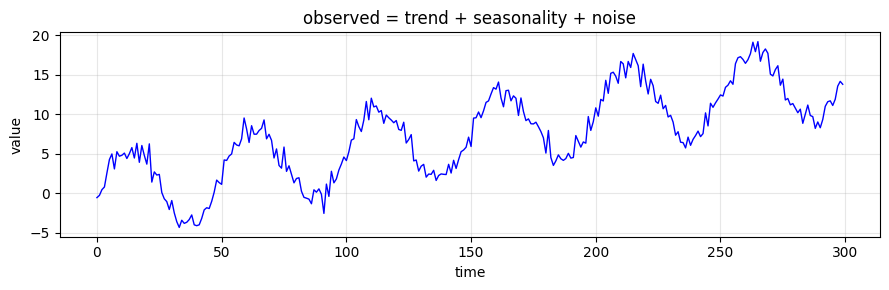

ADF: -1.84
p-value: 0.360


In [23]:
run_sequence_plot(trend_season, title="observed = trend + seasonality + noise")
plt.tight_layout(); plt.show()

adf_ts, pvalue_ts, _, _, _, _ = adfuller(trend_season)
print(f"ADF: {adf_ts:.2f}")
print(f"p-value: {pvalue_ts:.3f}")

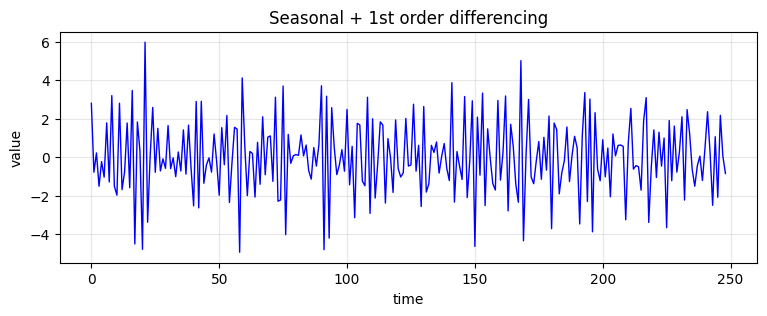

In [28]:
trend_seasonality_d50 = (trend_season[:-50] 
                         - trend_season[50:]) # remove seasonality
trend_seasonality_d50_d1 = (trend_seasonality_d50[:-1] 
                            - trend_seasonality_d50[1:]) # remove trend

# Plot the differenced time series
run_sequence_plot(trend_seasonality_d50_d1, title="Seasonal + 1st order differencing");

In [29]:
adf_after, pvalue_after, _, _, _, _ = adfuller(trend_seasonality_d50_d1)
print(f"ADF: {adf_after:.2f}")
print(f"p-value: {pvalue_after:.3f}")

ADF: -7.93
p-value: 0.000


## Inverting the transformations

Models are fitted on the transformed scale, but forecasts must be reported on the original one. Keep the
inverse in mind as you transform:

| Forward | Inverse |
|---|---|
| $y = \log x$ | $x = e^{y}$ (plus the shift, if you shifted) |
| Box-Cox $\lambda$ | `scipy.special.inv_boxcox(y, lam)` |
| $\Delta x$ | cumulative sum, plus the last observed value |
| $\Delta_L x$ | cumulative sum in steps of $L$, plus the last $L$ observed values |

# Summary

1. **Stationary** (weakly) = constant mean, constant finite variance, autocovariance that depends only on the lag. It is a property of the *process*, assessed from one *realization*.
2. Stationarity is what makes estimation meaningful and what every ARMA-family model assumes. Nonstationary series also generate **spurious** relationships.
3. **Look first.** Run-sequence plot, then chunk/rolling statistics, then the ACF. Slow ACF decay means "difference me".
4. **ADF**: $H_0$ = unit root, so $p < 0.05$ means stationary. 
5. Neither test sees changing **variance** or seasonality, and both have low power on short samples. They supplement the plots, they do not replace them.
6. **Transform in order**: variance (log/Box-Cox) $\rightarrow$ seasonality (seasonal difference)
   $\rightarrow$ trend (first difference). Differencing more than twice is almost always wrong; a large negative lag-1 autocorrelation means you went one step too far.
7. Every transformation must be **invertible**, because forecasts have to come back to the original scale.